In [28]:
import numpy as np
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd

In [33]:
name = '4mmtp'
data_dir = f'/home/kale-chen/Documents/PET/MDA_10112025/{name}.bin'
num_cols = 3
num_rows = os.path.getsize(data_dir) // (num_cols * np.int16().itemsize)
data = np.memmap(data_dir, dtype = np.int16, mode = 'r', shape = (num_rows, num_cols))
event_counts = np.zeros((3072, 3072), dtype = np.int32)
for i in tqdm(range(0, num_rows, 1000000), desc=''):
    chunk = data[i:i+1000000]
    idls = np.asarray(chunk[:, 0], dtype = np.int32)
    idrs = np.asarray(chunk[:, 1], dtype = np.int32)
    np.add.at(event_counts, (idls, idrs), 1)
print(np.sum(event_counts))

100%|██████████| 1/1 [00:00<00:00,  7.33it/s]

638640


In [34]:
require_cos = 0.0

norm_factors = np.fromfile('norm_factors.bin', dtype = np.float32).reshape(3072, 3072)


if require_cos > 0:
    mapdf = pd.read_csv('/home/kale-chen/Documents/PET/TPPT_Scanner_map_adjusted.csv', header = None)
    coords = np.asarray(mapdf.iloc[:, 0:3], dtype = np.float32)
    directions = np.asarray(mapdf.iloc[:, 3:6], dtype = np.float32)
def get_geommetric_correction(idl, idr): # Get the cosine of the relative angle between two crystals
    lor_vector = coords[idr] - coords[idl]
    lor_vector = lor_vector / np.linalg.norm(lor_vector) # Normalize
    cosidl = np.dot(directions[idl], lor_vector)
    cosidr = np.dot(directions[idr], lor_vector)
    return np.abs(cosidl * cosidr)
if require_cos > 0:
    mask = np.zeros((3072, 3072), dtype = np.bool)
    for idl in tqdm(range(3072), desc='Creating mask'):
        for idr in range(3072):
            if get_geommetric_correction(idl + 3072, idr) > require_cos:
                mask[idl, idr] = True
else:
    mask = np.ones((3072, 3072), dtype = np.bool)



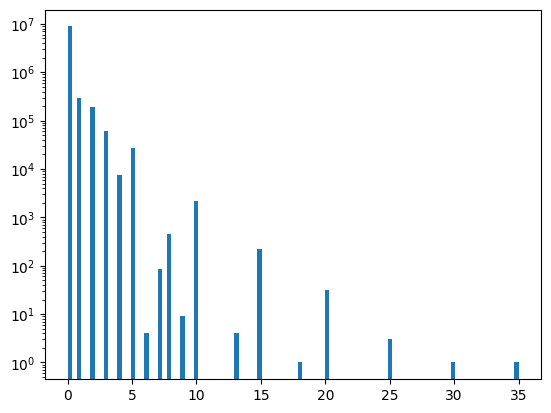

In [35]:
event_counts_boosted = event_counts * norm_factors * mask
event_counts_boosted = np.ceil(event_counts_boosted).astype(np.int32)
plt.hist(event_counts_boosted.flatten(), bins = 100)
plt.yscale('log')
plt.show()

In [36]:
out_data = '4mmtpBOOST.bin'
if os.path.exists(out_data):
    os.remove(out_data)
with open(out_data, 'wb') as f:
    total = 0
    for i in tqdm(range(num_rows), desc='Copying'):
        idl, idr = data[i, 0], data[i, 1]
        for n in range(event_counts_boosted[idl, idr]):
            f.write(data[i].tobytes())
            total += 1
print(total)

Copying: 100%|██████████| 638640/638640 [00:02<00:00, 252373.92it/s]

1237285
